# Discovering a native complex geometric Brownian motion

This notebook records the constructive and computational route to

\[
\mathcal{Z}_t=\mathcal{Z}_0
\exp\!\left(
\left[\left(\mu-\frac12\sigma^2\right)+i\omega\right]t
+(\sigma+i\beta)W_t
\right).
\]

We begin with desired log-radius and phase dynamics, reconcile the
ordinary exponential with the complex Itô SDE, and then test the
pathwise identities, transition laws, moments, covariance rank,
Euler--Maruyama convergence, and quadratic variations. The notebook
generates every figure and numerical table used by the Phase 4 paper.
Analytic claims are proved in the manuscript; seeded simulations are
diagnostics, not proofs.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import patches
import nbformat
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import seaborn as sns
import sympy as sp


def locate_roots() -> tuple[Path, Path]:
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    for repository_root in candidates:
        phase4_root = repository_root / "paper" / "phase4"
        if (
            (repository_root / "phase4_model.py").exists()
            and (phase4_root / "_quarto.yml").exists()
        ):
            return repository_root, phase4_root
    raise RuntimeError("Could not locate repository and Phase 4 paper roots")


REPOSITORY_ROOT, PAPER_ROOT = locate_roots()
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

from phase4_model import (
    ComplexGBMParameters,
    complex_bracket_rates,
    complex_moment,
    euler_maruyama_path,
    exact_path,
    exact_step,
    gbm_radius,
    log_polar_covariance,
    mixed_log_polar_moment,
    radial_moment,
    two_driver_path,
    unwrapped_phase,
)

VECTOR_DIR = PAPER_ROOT / "figures" / "vector"
RASTER_DIR = PAPER_ROOT / "figures" / "raster"
TABLE_DIR = PAPER_ROOT / "tables"
for directory in (VECTOR_DIR, RASTER_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

BASE_SEED = 20260724
FIGURE_ROWS: list[dict[str, str]] = []
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#1B1B1B",
    "gray": "#737373",
}

sns.set_theme(context="paper", style="whitegrid")
matplotlib.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.bbox": "tight",
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "font.size": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)
np.set_printoptions(precision=8, suppress=True)


def assert_inside_phase4(path: Path) -> Path:
    '''Reject output paths escaping the Phase 4 paper root.'''
    resolved = path.resolve()
    resolved.relative_to(PAPER_ROOT.resolve())
    return resolved


def save_figure(fig: plt.Figure, stem: str, alt_text: str) -> None:
    '''Save vector PDF and raster PNG companions under paper/phase4.'''
    if not stem.startswith("f") or len(alt_text.strip()) < 20:
        raise ValueError("figure stems and descriptive alt text are required")
    vector_path = assert_inside_phase4(VECTOR_DIR / f"{stem}.pdf")
    raster_path = assert_inside_phase4(RASTER_DIR / f"{stem}.png")
    fig.savefig(vector_path)
    fig.savefig(raster_path, dpi=300)
    FIGURE_ROWS.append(
        {
            "stem": stem,
            "vector": vector_path.relative_to(PAPER_ROOT).as_posix(),
            "raster": raster_path.relative_to(PAPER_ROOT).as_posix(),
            "alt_text": alt_text.strip(),
        }
    )
    plt.show()
    plt.close(fig)


def write_csv(name: str, frame: pd.DataFrame) -> None:
    '''Write a deterministic CSV with stable column order.'''
    path = assert_inside_phase4(TABLE_DIR / name)
    if path.suffix != ".csv":
        raise ValueError("CSV output name must end in .csv")
    frame.to_csv(path, index=False, lineterminator="\n")


def write_json(name: str, payload: dict[str, object]) -> None:
    '''Write sorted, indented JSON without nonfinite values.'''
    path = assert_inside_phase4(TABLE_DIR / name)
    if path.suffix != ".json":
        raise ValueError("JSON output name must end in .json")
    encoded = json.dumps(payload, indent=2, sort_keys=True, allow_nan=False)
    path.write_text(encoded + "\n", encoding="utf-8")


version_rows = [
    ("Python", sys.version.split()[0]),
    ("NumPy", np.__version__),
    ("SciPy", scipy.__version__),
    ("pandas", pd.__version__),
    ("Matplotlib", matplotlib.__version__),
    ("Seaborn", sns.__version__),
    ("SymPy", sp.__version__),
    ("nbformat", nbformat.__version__),
    ("platform", platform.platform()),
    ("conda environment", os.environ.get("CONDA_DEFAULT_ENV", "unknown")),
    ("master seed", str(BASE_SEED)),
]
version_table = pd.DataFrame(version_rows, columns=["component", "version"])
write_csv("software_versions.csv", version_table)
version_table

,component,version
0,Python,3.12.13
1,NumPy,2.5.1
2,SciPy,1.18.0
3,pandas,3.0.3
4,Matplotlib,3.11.1
5,Seaborn,0.13.2
6,SymPy,1.14.0
7,nbformat,5.10.4
8,platform,Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43
9,conda environment,phase3-paper


## 1. Requirements and coefficient reconciliation

Prescribe a real GBM modulus and a continuous phase lift:

\[
\frac{dR_t}{R_t}=\mu\,dt+\sigma\,dW_t,\qquad
d\Theta_t=\omega\,dt+\beta\,dW_t.
\]

The direct complex log increment is

\[
\kappa\,dt+B\,dW_t,\qquad
\kappa=\left(\mu-\frac12\sigma^2\right)+i\omega,\quad
B=\sigma+i\beta.
\]

For \(Z_t=Z_0e^{\kappa t+BW_t}\), Itô's formula gives
\(dZ_t/Z_t=A\,dt+B\,dW_t\), where

\[
A=\kappa+\frac12B^2
=\mu-\frac12\beta^2+i(\omega+\sigma\beta).
\]

The complex square \(B^2\), not \(|B|^2\), supplies the correction.

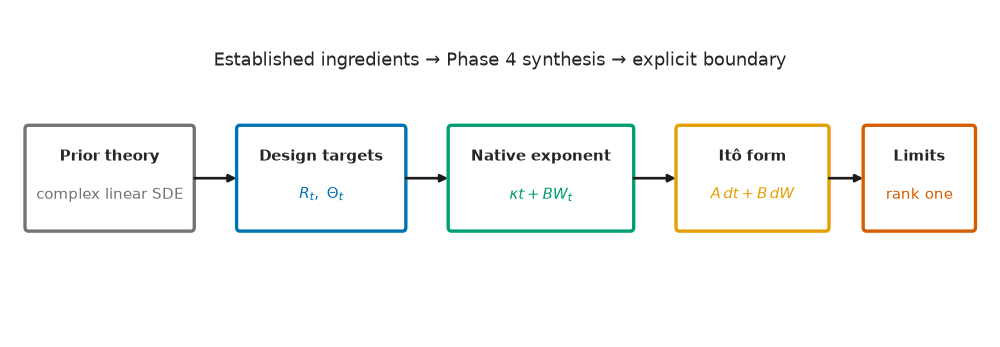

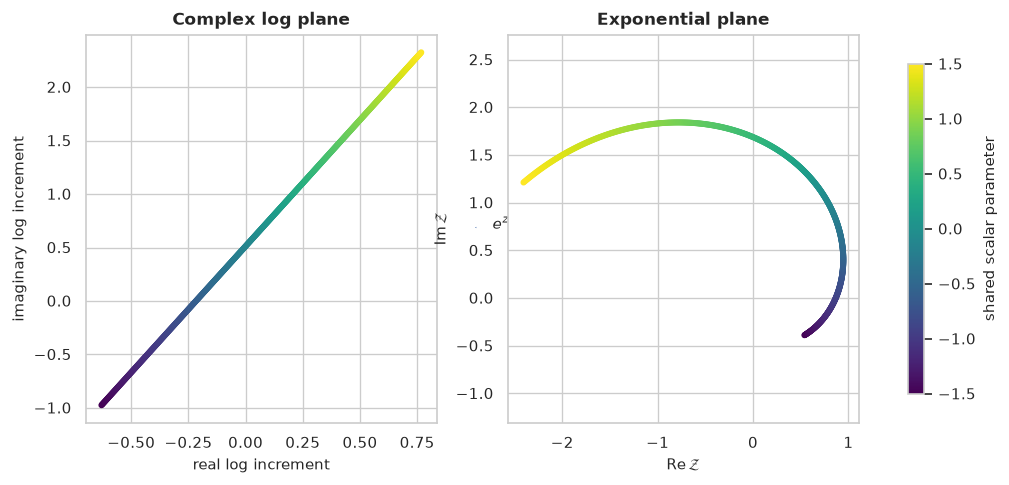

,coefficient,real_part,imaginary_part
0,log drift kappa,0.09180,0.900
1,diffusion B,0.42000,0.650
2,Ito drift A,-0.03125,1.173
3,A - B^2/2,0.09180,0.900


In [2]:
MU = 0.18
SIGMA = 0.42
OMEGA = 0.90
BETA = 0.65
R0 = 1.25
THETA0 = 0.35
Z0 = R0 * np.exp(1j * THETA0)
T = 1.50
PARAMS = ComplexGBMParameters(MU, SIGMA, OMEGA, BETA)

kappa = PARAMS.log_drift
B = PARAMS.diffusion
A = PARAMS.sde_drift
coefficient_error = abs(A - 0.5 * B**2 - kappa)
assert coefficient_error < 2e-15

coefficient_table = pd.DataFrame(
    [
        ("log drift kappa", kappa.real, kappa.imag),
        ("diffusion B", B.real, B.imag),
        ("Ito drift A", A.real, A.imag),
        ("A - B^2/2", (A - 0.5 * B**2).real, (A - 0.5 * B**2).imag),
    ],
    columns=["coefficient", "real_part", "imaginary_part"],
)
write_csv("coefficient_reconciliation.csv", coefficient_table)

fig, ax = plt.subplots(figsize=(10.5, 3.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3.3)
ax.axis("off")
nodes = [
    (0.2, 1.1, 2.0, 1.0, "Prior theory", "complex linear SDE", COLORS["gray"]),
    (2.8, 1.1, 2.0, 1.0, "Design targets", r"$R_t,\ \Theta_t$", COLORS["blue"]),
    (5.4, 1.1, 2.2, 1.0, "Native exponent", r"$\kappa t+BW_t$", COLORS["green"]),
    (8.2, 1.1, 1.8, 1.0, "Itô form", r"$A\,dt+B\,dW$", COLORS["orange"]),
    (10.5, 1.1, 1.3, 1.0, "Limits", "rank one", COLORS["red"]),
]
for x, y, width, height, heading, detail, color in nodes:
    box = patches.FancyBboxPatch(
        (x, y), width, height, boxstyle="round,pad=0.04",
        facecolor="white", edgecolor=color, linewidth=2
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + 0.68, heading, ha="center", weight="bold")
    ax.text(x + width / 2, y + 0.29, detail, ha="center", color=color)
for left, right in [(2.2, 2.8), (4.8, 5.4), (7.6, 8.2), (10.0, 10.5)]:
    ax.annotate(
        "", xy=(right, 1.6), xytext=(left, 1.6),
        arrowprops=dict(arrowstyle="-|>", color=COLORS["black"], lw=1.6)
    )
ax.text(6.0, 2.75, "Established ingredients → Phase 4 synthesis → explicit boundary",
        ha="center", fontsize=11)
save_figure(
    fig,
    "f01_research_claim_map",
    "Flow diagram separating established complex linear SDE theory from the Phase 4 parameter synthesis and its rank-one limitation.",
)

x = np.linspace(-1.5, 1.5, 700)
log_line = kappa * (x - x.min()) / (x.max() - x.min()) * T + B * x
exponential_line = Z0 * np.exp(log_line)
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))
points = axes[0].scatter(log_line.real, log_line.imag, c=x, cmap="viridis", s=8)
axes[0].set_xlabel("real log increment")
axes[0].set_ylabel("imaginary log increment")
axes[0].set_title("Complex log plane")
axes[0].annotate(
    r"$e^z$", xy=(1.08, 0.5), xycoords="axes fraction",
    xytext=(1.18, 0.5), textcoords="axes fraction",
    arrowprops=dict(arrowstyle="-|>", lw=1.7), ha="center"
)
axes[1].scatter(
    exponential_line.real, exponential_line.imag, c=x,
    cmap="viridis", s=8
)
axes[1].set_aspect("equal", adjustable="datalim")
axes[1].set_xlabel(r"$\operatorname{Re}\mathcal{Z}$")
axes[1].set_ylabel(r"$\operatorname{Im}\mathcal{Z}$")
axes[1].set_title("Exponential plane")
fig.colorbar(points, ax=axes, label="shared scalar parameter", shrink=0.85)
save_figure(
    fig,
    "f02_log_to_exponential_plane",
    "A colored line in the complex log plane maps through the exponential to a rotating curve with changing radius in the complex plane.",
)
coefficient_table

## 2. Pathwise modulus, phase, and exactness

Taking real and imaginary parts of the exponent gives

\[
R_t=R_0e^{(\mu-\sigma^2/2)t+\sigma W_t},\qquad
\Theta_t=\Theta_0+\omega t+\beta W_t.
\]

Thus \(R\) is exactly the prescribed real GBM, while the imaginary
exponent is a continuous unwrapped phase. The complex exponential
never reaches zero when \(Z_0\ne0\), so this phase lift is available
for every finite time on each path.

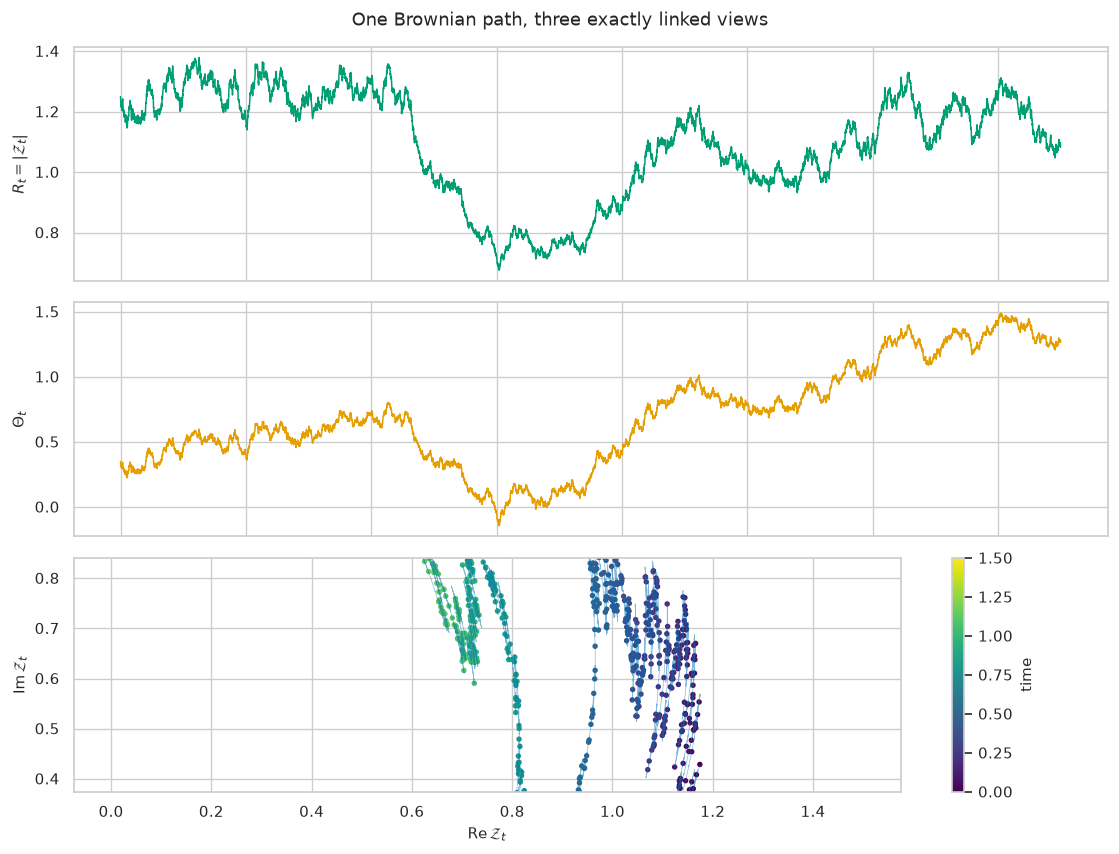

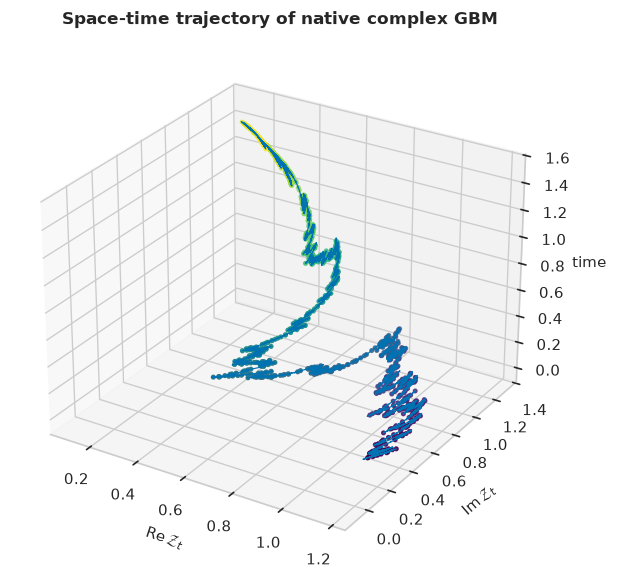

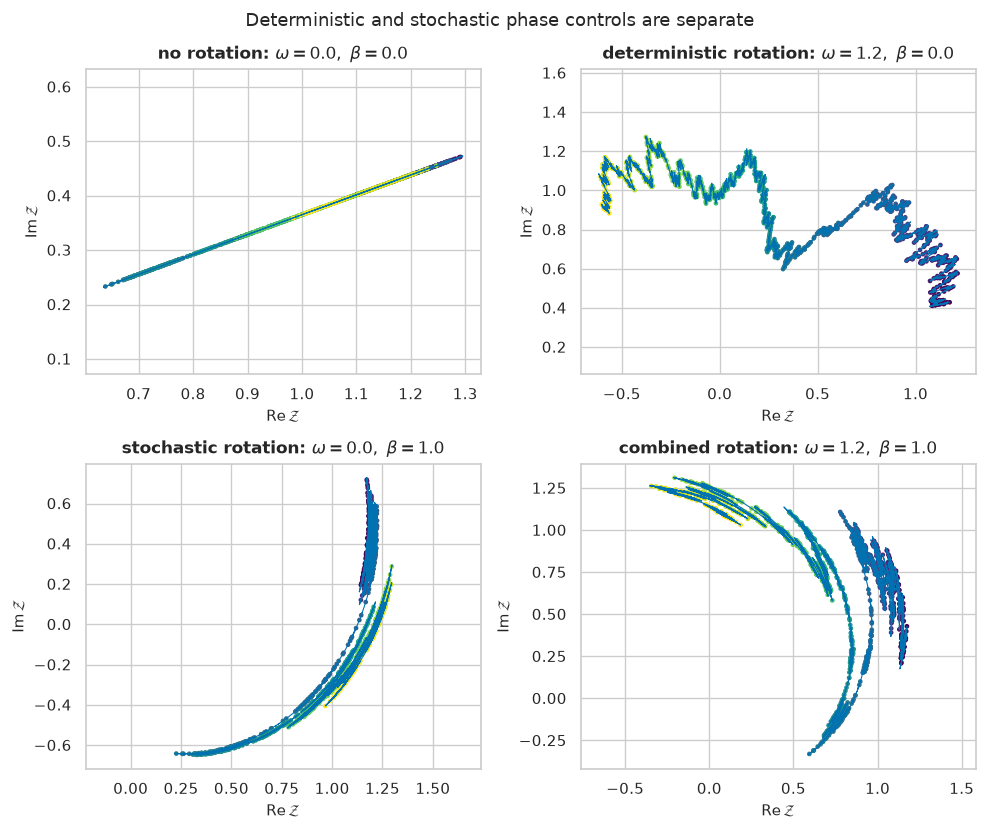

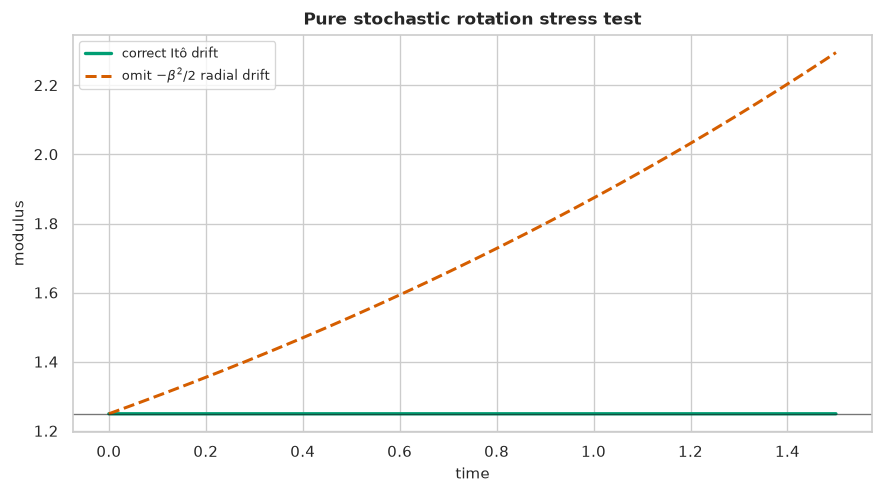

{'coefficient_error': 0.0,
 'constant_modulus_error': 4.440892098500626e-16,
 'modulus_error': 4.440892098500626e-16,
 'phase_error': 4.440892098500626e-16,
 'reconstruction_error': 6.661338147750939e-16,
 'transition_error': 1.1443916996305594e-16}

In [3]:
n_path = 8192
h_path = T / n_path
rng_path = np.random.default_rng(BASE_SEED + 1)
dW_path = np.sqrt(h_path) * rng_path.standard_normal(n_path)
times = np.linspace(0.0, T, n_path + 1)
brownian = np.concatenate(([0.0], np.cumsum(dW_path)))
z_path = exact_path(times, brownian, Z0, PARAMS)
radius = gbm_radius(times, brownian, R0, PARAMS)
phase = unwrapped_phase(times, brownian, THETA0, PARAMS)
reconstructed = radius * np.exp(1j * phase)

modulus_error = float(np.max(np.abs(np.abs(z_path) - radius)))
reconstruction_error = float(np.max(np.abs(z_path - reconstructed)))
phase_error = float(
    np.max(np.abs(np.unwrap(np.angle(z_path)) - phase))
)
step_index = 3117
transition = exact_step(
    z_path[step_index],
    times[step_index + 1] - times[step_index],
    brownian[step_index + 1] - brownian[step_index],
    PARAMS,
)
transition_error = float(abs(transition - z_path[step_index + 1]))

constant_params = ComplexGBMParameters(0.0, 0.0, 0.35, 0.90)
constant_z = exact_path(times, brownian, Z0, constant_params)
constant_modulus_error = float(np.max(np.abs(np.abs(constant_z) - R0)))

exactness = {
    "coefficient_error": coefficient_error,
    "constant_modulus_error": constant_modulus_error,
    "modulus_error": modulus_error,
    "phase_error": phase_error,
    "reconstruction_error": reconstruction_error,
    "transition_error": transition_error,
}
assert max(exactness.values()) < 2e-13
write_json("exactness.json", exactness)

sample = np.linspace(0, n_path, 1200, dtype=int)
fig, axes = plt.subplots(3, 1, figsize=(9.4, 7.2), sharex=True)
axes[0].plot(times, radius, color=COLORS["green"], lw=0.9)
axes[0].set_ylabel(r"$R_t=|\mathcal{Z}_t|$")
axes[1].plot(times, phase, color=COLORS["orange"], lw=0.9)
axes[1].set_ylabel(r"$\Theta_t$")
scatter = axes[2].scatter(
    z_path.real[sample], z_path.imag[sample], c=times[sample],
    cmap="viridis", s=6
)
axes[2].plot(z_path.real, z_path.imag, color=COLORS["blue"], lw=0.4, alpha=0.5)
axes[2].set_xlabel(r"$\operatorname{Re}\mathcal{Z}_t$")
axes[2].set_ylabel(r"$\operatorname{Im}\mathcal{Z}_t$")
axes[2].set_aspect("equal", adjustable="datalim")
fig.colorbar(scatter, ax=axes[2], label="time")
fig.suptitle("One Brownian path, three exactly linked views")
fig.tight_layout()
save_figure(
    fig,
    "f03_linked_modulus_phase_path",
    "Three panels show the exact GBM modulus, continuous unwrapped phase, and resulting complex trajectory generated by one Brownian path.",
)

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(z_path.real, z_path.imag, times, color=COLORS["blue"], lw=0.7)
ax.scatter(
    z_path.real[sample], z_path.imag[sample], times[sample],
    c=times[sample], cmap="viridis", s=5, rasterized=True
)
ax.set_xlabel(r"$\operatorname{Re}\mathcal{Z}_t$")
ax.set_ylabel(r"$\operatorname{Im}\mathcal{Z}_t$")
ax.set_zlabel("time")
ax.set_title("Space-time trajectory of native complex GBM")
ax.view_init(elev=27, azim=-58)
save_figure(
    fig,
    "f04_space_time_trajectory",
    "Three-dimensional curve showing real part, imaginary part, and time for one exact native complex geometric Brownian motion path.",
)

gallery = [
    (0.0, 0.0, "no rotation"),
    (1.2, 0.0, "deterministic rotation"),
    (0.0, 1.0, "stochastic rotation"),
    (1.2, 1.0, "combined rotation"),
]
fig, axes = plt.subplots(2, 2, figsize=(8.4, 7.0))
for ax, (omega_case, beta_case, title) in zip(axes.flat, gallery):
    p_case = ComplexGBMParameters(MU, SIGMA, omega_case, beta_case)
    z_case = exact_path(times, brownian, Z0, p_case)
    ax.plot(z_case.real, z_case.imag, lw=0.65, color=COLORS["blue"])
    ax.scatter(
        z_case.real[sample], z_case.imag[sample], c=times[sample],
        cmap="viridis", s=4, rasterized=True
    )
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(title + rf": $\omega={omega_case:.1f},\ \beta={beta_case:.1f}$")
    ax.set_xlabel(r"$\operatorname{Re}\mathcal{Z}$")
    ax.set_ylabel(r"$\operatorname{Im}\mathcal{Z}$")
fig.suptitle("Deterministic and stochastic phase controls are separate")
fig.tight_layout()
save_figure(
    fig,
    "f05_rotation_parameter_gallery",
    "Four complex paths compare absent, deterministic, stochastic, and combined rotation while keeping the same radial GBM parameters and Brownian path.",
)

naive_radius = R0 * np.exp(0.5 * constant_params.beta**2 * times)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.plot(times, np.abs(constant_z), color=COLORS["green"], lw=2.0,
        label="correct Itô drift")
ax.plot(times, naive_radius, color=COLORS["red"], lw=1.8, ls="--",
        label=r"omit $-\beta^2/2$ radial drift")
ax.axhline(R0, color=COLORS["black"], lw=0.8, alpha=0.6)
ax.set_xlabel("time")
ax.set_ylabel("modulus")
ax.set_title("Pure stochastic rotation stress test")
ax.legend()
save_figure(
    fig,
    "f06_constant_modulus_correction",
    "The correctly compensated pure stochastic rotation keeps constant modulus, while omitting the negative half beta-squared Itô drift creates spurious radial growth.",
)
exactness

## 3. Exact multiplicative walk and transition geometry

For a finite step \(h\) and Brownian increment
\(\Delta W_n\sim N(0,h)\),

\[
\mathcal{Z}_{n+1}
=\mathcal{Z}_n
\exp\!\left(\kappa h+B\Delta W_n\right).
\]

This is the requested random-walk formula: the real and imaginary
parts of one complex log increment combine scale and rotation. At a
fixed horizon, log-radius and phase are jointly Gaussian but are
driven by one scalar normal variable, so their covariance is rank one
and their support is a line in log-polar space.

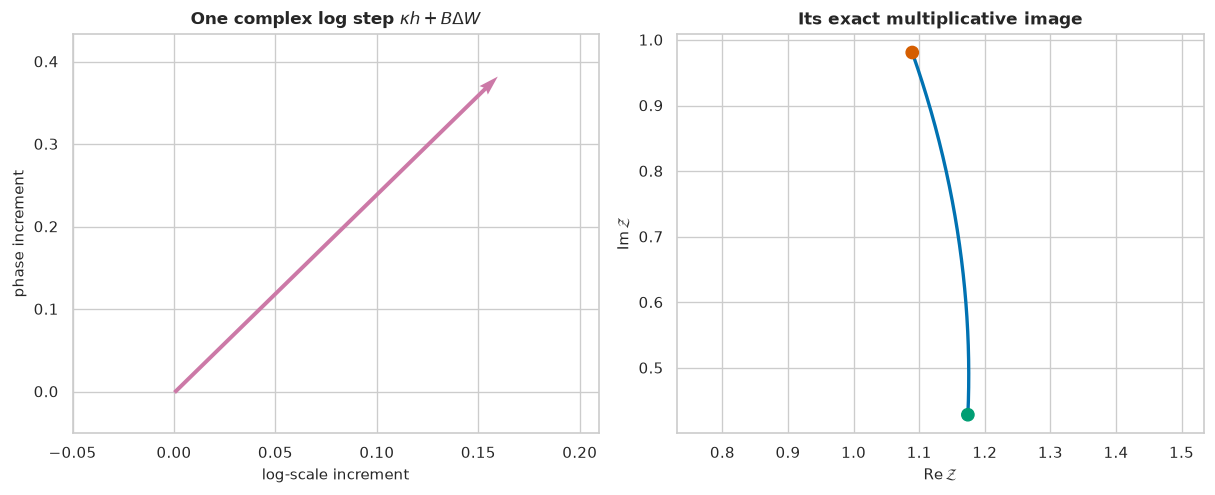

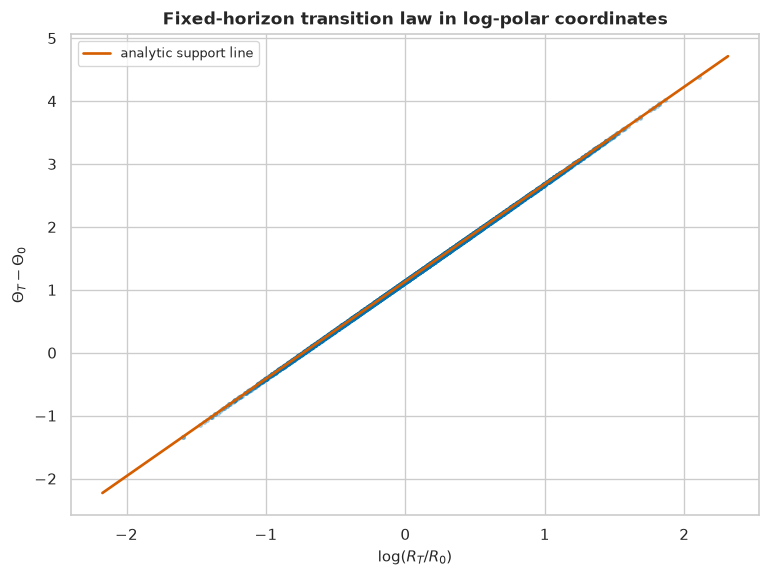

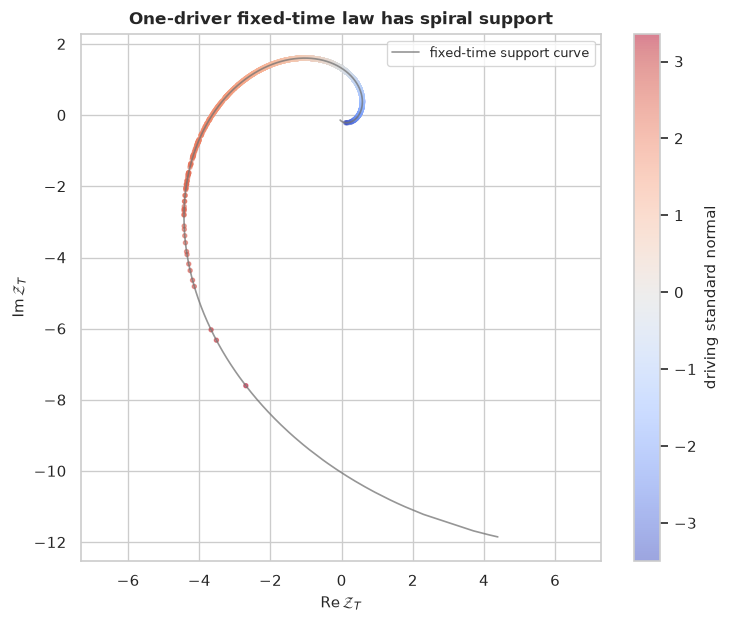

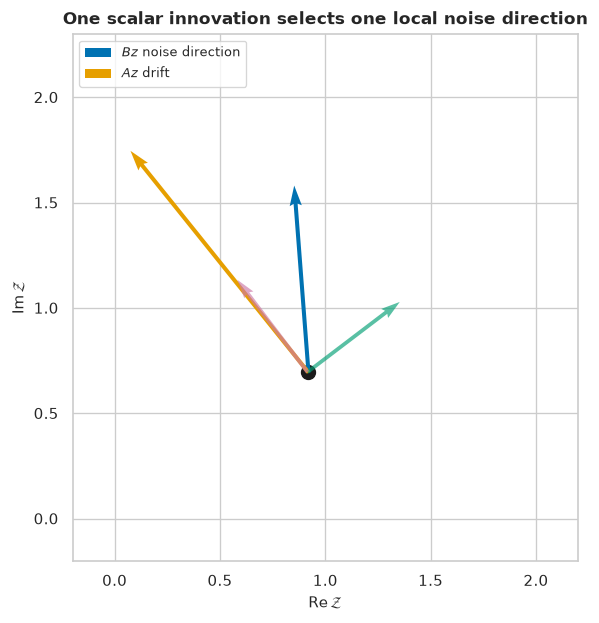

,variable,empirical_mean,analytic_mean,empirical_variance,analytic_variance
0,log_radius,0.136814,0.1377,0.265700,0.26460
1,phase,1.348629,1.3500,0.636384,0.63375


In [4]:
h_demo = 0.18
dW_demo = 0.34
log_step = kappa * h_demo + B * dW_demo
substeps = np.linspace(0.0, 1.0, 300)
z_step_curve = Z0 * np.exp(substeps * log_step)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
axes[0].quiver(
    [0.0], [0.0], [log_step.real], [log_step.imag],
    angles="xy", scale_units="xy", scale=1.0, color=COLORS["purple"]
)
axes[0].set_xlim(min(-0.05, log_step.real - 0.05), max(0.15, log_step.real + 0.05))
axes[0].set_ylim(min(-0.05, log_step.imag - 0.05), max(0.15, log_step.imag + 0.05))
axes[0].set_xlabel("log-scale increment")
axes[0].set_ylabel("phase increment")
axes[0].set_title(r"One complex log step $\kappa h+B\Delta W$")
axes[1].plot(z_step_curve.real, z_step_curve.imag, color=COLORS["blue"], lw=2)
axes[1].scatter(
    [z_step_curve[0].real, z_step_curve[-1].real],
    [z_step_curve[0].imag, z_step_curve[-1].imag],
    c=[COLORS["green"], COLORS["red"]], s=55, zorder=3
)
axes[1].set_aspect("equal", adjustable="datalim")
axes[1].set_xlabel(r"$\operatorname{Re}\mathcal{Z}$")
axes[1].set_ylabel(r"$\operatorname{Im}\mathcal{Z}$")
axes[1].set_title("Its exact multiplicative image")
fig.tight_layout()
save_figure(
    fig,
    "f07_exact_step_geometry",
    "A complex log increment is shown as one vector whose exponential maps an initial state to the next state along a scale-and-rotation arc.",
)

n_cov = 250_000
rng_cov = np.random.default_rng(BASE_SEED + 2)
normals = rng_cov.standard_normal(n_cov)
log_radius_increment = (MU - 0.5 * SIGMA**2) * T + SIGMA * np.sqrt(T) * normals
phase_increment = OMEGA * T + BETA * np.sqrt(T) * normals
centered = np.column_stack(
    (
        log_radius_increment - (MU - 0.5 * SIGMA**2) * T,
        phase_increment - OMEGA * T,
    )
)
empirical_one_cov = np.cov(centered, rowvar=False, ddof=1) / T
analytic_one_cov = log_polar_covariance(PARAMS)

view = np.linspace(0, n_cov - 1, 6000, dtype=int)
fig, ax = plt.subplots(figsize=(7.4, 5.2))
ax.scatter(
    log_radius_increment[view], phase_increment[view],
    s=5, alpha=0.25, color=COLORS["blue"], rasterized=True
)
lr = np.linspace(log_radius_increment.min(), log_radius_increment.max(), 300)
line = OMEGA * T + (BETA / SIGMA) * (
    lr - (MU - 0.5 * SIGMA**2) * T
)
ax.plot(lr, line, color=COLORS["red"], lw=1.6, label="analytic support line")
ax.set_xlabel(r"$\log(R_T/R_0)$")
ax.set_ylabel(r"$\Theta_T-\Theta_0$")
ax.set_title("Fixed-horizon transition law in log-polar coordinates")
ax.legend()
save_figure(
    fig,
    "f08_log_polar_transition",
    "A fixed-horizon log-radius and phase sample lies on the analytic rank-one Gaussian support line in log-polar coordinates.",
)

z_terminal = Z0 * np.exp(log_radius_increment + 1j * phase_increment)
order = np.argsort(log_radius_increment)
fig, ax = plt.subplots(figsize=(7.0, 5.7))
ax.plot(
    z_terminal.real[order], z_terminal.imag[order],
    color=COLORS["gray"], lw=1.0, alpha=0.75,
    label="fixed-time support curve"
)
sample_terminal = rng_cov.choice(n_cov, 3500, replace=False)
scatter = ax.scatter(
    z_terminal.real[sample_terminal], z_terminal.imag[sample_terminal],
    c=normals[sample_terminal], cmap="coolwarm", s=6, alpha=0.5,
    rasterized=True
)
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel(r"$\operatorname{Re}\mathcal{Z}_T$")
ax.set_ylabel(r"$\operatorname{Im}\mathcal{Z}_T$")
ax.set_title("One-driver fixed-time law has spiral support")
ax.legend()
fig.colorbar(scatter, ax=ax, label="driving standard normal")
save_figure(
    fig,
    "f09_fixed_time_spiral_support",
    "Terminal complex samples from one real Brownian driver lie on a one-dimensional logarithmic spiral rather than filling a two-dimensional region.",
)

z_anchor = 1.15 * np.exp(0.65j)
noise_direction = B * z_anchor
drift_direction = A * z_anchor
fig, ax = plt.subplots(figsize=(6.4, 5.7))
ax.scatter([z_anchor.real], [z_anchor.imag], s=70, color=COLORS["black"])
ax.quiver(
    [z_anchor.real], [z_anchor.imag],
    [noise_direction.real], [noise_direction.imag],
    angles="xy", scale_units="xy", scale=1.0,
    color=COLORS["blue"], width=0.008, label=r"$Bz$ noise direction"
)
ax.quiver(
    [z_anchor.real], [z_anchor.imag],
    [drift_direction.real], [drift_direction.imag],
    angles="xy", scale_units="xy", scale=1.0,
    color=COLORS["orange"], width=0.008, label=r"$Az$ drift"
)
radial_unit = z_anchor / abs(z_anchor)
tangent_unit = 1j * radial_unit
ax.quiver(
    [z_anchor.real, z_anchor.real], [z_anchor.imag, z_anchor.imag],
    [0.55 * radial_unit.real, 0.55 * tangent_unit.real],
    [0.55 * radial_unit.imag, 0.55 * tangent_unit.imag],
    angles="xy", scale_units="xy", scale=1.0,
    color=[COLORS["green"], COLORS["purple"]], alpha=0.65
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.2, 2.2)
ax.set_ylim(-0.2, 2.3)
ax.set_xlabel(r"$\operatorname{Re}\mathcal{Z}$")
ax.set_ylabel(r"$\operatorname{Im}\mathcal{Z}$")
ax.set_title("One scalar innovation selects one local noise direction")
ax.legend(loc="upper left")
save_figure(
    fig,
    "f10_local_noise_direction",
    "At one complex state, the diffusion vector has radial and tangential components but remains a single local noise direction driven by one scalar Brownian increment.",
)

transition_table = pd.DataFrame(
    [
        ("log_radius", np.mean(log_radius_increment), (MU - 0.5 * SIGMA**2) * T,
         np.var(log_radius_increment, ddof=1), SIGMA**2 * T),
        ("phase", np.mean(phase_increment), OMEGA * T,
         np.var(phase_increment, ddof=1), BETA**2 * T),
    ],
    columns=["variable", "empirical_mean", "analytic_mean", "empirical_variance", "analytic_variance"],
)
write_csv("transition_summary.csv", transition_table)
transition_table

## 4. Noise dimension: one driver versus two

The instantaneous covariance of log-radius and phase is

\[
\Sigma_1=
\begin{pmatrix}\sigma\\\beta\end{pmatrix}
\begin{pmatrix}\sigma&\beta\end{pmatrix},
\]

an outer product with rank at most one. An independent two-driver
comparator has covariance
\(\Sigma_2=\operatorname{diag}(\sigma^2,\beta^2)\), which has rank two
when both coefficients are nonzero. Complex notation combines
directions; it does not create a second source of randomness.

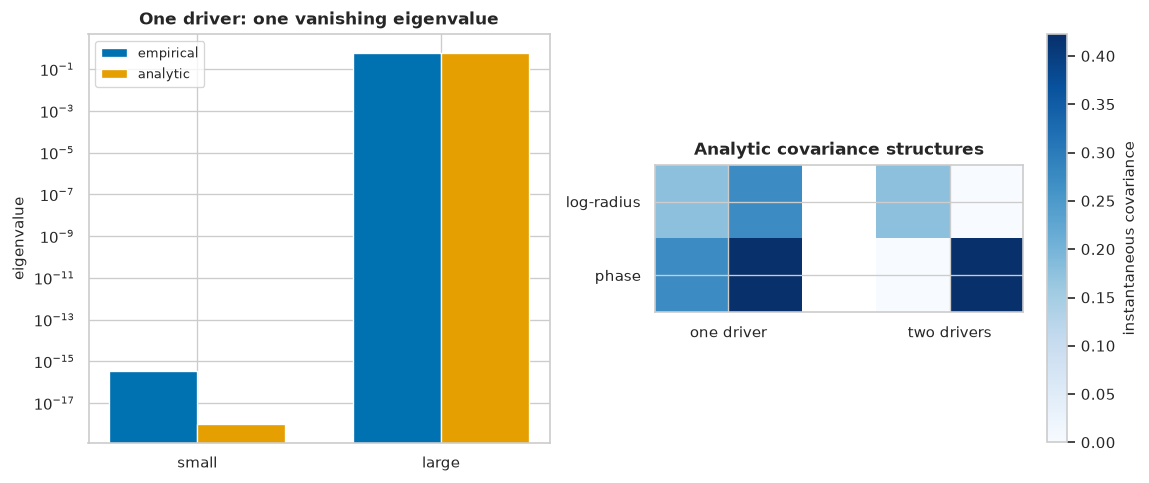

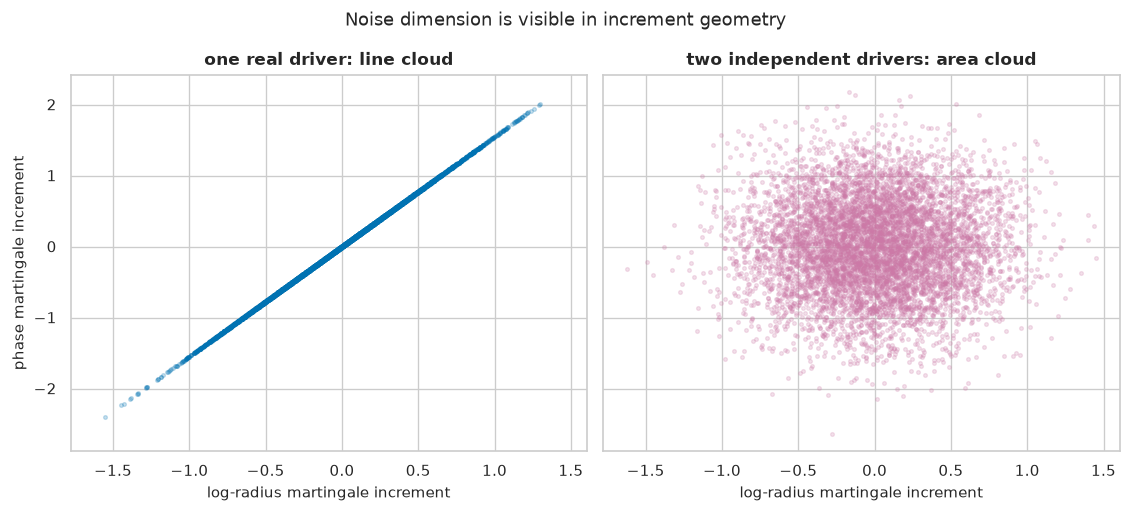

,model,empirical_00,empirical_01,empirical_11,analytic_00,analytic_01,analytic_11,small_eigenvalue,large_eigenvalue,numerical_rank
0,one_driver,0.177133,0.274135,0.424256,0.1764,0.273,0.4225,3.330669e-16,0.601389,1
1,two_driver,0.176007,0.000248,0.423186,0.1764,0.000,0.4225,1.760070e-01,0.423186,2


In [5]:
one_eigenvalues = np.linalg.eigvalsh(empirical_one_cov)
analytic_one_eigenvalues = np.linalg.eigvalsh(analytic_one_cov)
rng_two = np.random.default_rng(BASE_SEED + 3)
normals_two = rng_two.standard_normal((n_cov, 2))
centered_two = np.column_stack(
    (SIGMA * normals_two[:, 0], BETA * normals_two[:, 1])
)
empirical_two_cov = np.cov(centered_two, rowvar=False, ddof=1)
analytic_two_cov = np.diag([SIGMA**2, BETA**2])
two_eigenvalues = np.linalg.eigvalsh(empirical_two_cov)

one_ratio = float(abs(one_eigenvalues[0]) / one_eigenvalues[-1])
assert one_ratio < 1e-12
assert np.linalg.matrix_rank(empirical_two_cov, tol=1e-4) == 2
assert np.allclose(empirical_one_cov, analytic_one_cov, rtol=0.012, atol=0.002)
assert np.allclose(empirical_two_cov, analytic_two_cov, rtol=0.012, atol=0.002)

covariance_rows = []
for model, empirical, analytic in [
    ("one_driver", empirical_one_cov, analytic_one_cov),
    ("two_driver", empirical_two_cov, analytic_two_cov),
]:
    eig = np.linalg.eigvalsh(empirical)
    covariance_rows.append(
        {
            "model": model,
            "empirical_00": empirical[0, 0],
            "empirical_01": empirical[0, 1],
            "empirical_11": empirical[1, 1],
            "analytic_00": analytic[0, 0],
            "analytic_01": analytic[0, 1],
            "analytic_11": analytic[1, 1],
            "small_eigenvalue": eig[0],
            "large_eigenvalue": eig[1],
            "numerical_rank": int(np.linalg.matrix_rank(empirical, tol=1e-4)),
        }
    )
covariance_table = pd.DataFrame(covariance_rows)
write_csv("covariance_rank.csv", covariance_table)

fig, axes = plt.subplots(1, 2, figsize=(9.7, 4.1))
labels = ["small", "large"]
positions = np.arange(2)
axes[0].bar(
    positions - 0.18, np.maximum(one_eigenvalues, 1e-18),
    width=0.36, color=COLORS["blue"], label="empirical"
)
axes[0].bar(
    positions + 0.18, np.maximum(analytic_one_eigenvalues, 1e-18),
    width=0.36, color=COLORS["orange"], label="analytic"
)
axes[0].set_yscale("log")
axes[0].set_xticks(positions, labels)
axes[0].set_ylabel("eigenvalue")
axes[0].set_title("One driver: one vanishing eigenvalue")
axes[0].legend()
matrices = [analytic_one_cov, analytic_two_cov]
titles = ["rank-one outer product", "rank-two diagonal"]
vmax = max(matrix.max() for matrix in matrices)
for matrix, title, shift in zip(matrices, titles, [-0.14, 0.14]):
    pass
image = axes[1].imshow(
    np.block([[analytic_one_cov, np.full((2, 1), np.nan), analytic_two_cov]]),
    cmap="Blues", vmin=0.0, vmax=vmax
)
axes[1].set_xticks([0.5, 3.5], ["one driver", "two drivers"])
axes[1].set_yticks([0, 1], ["log-radius", "phase"])
axes[1].set_title("Analytic covariance structures")
fig.colorbar(image, ax=axes[1], label="instantaneous covariance")
fig.tight_layout()
save_figure(
    fig,
    "f11_covariance_eigenspectrum",
    "The one-driver covariance has one numerically vanishing eigenvalue, while a companion heatmap contrasts its outer-product structure with the two-driver diagonal covariance.",
)

cloud_n = 7000
one_cloud = centered[:cloud_n] / np.sqrt(T)
two_cloud = centered_two[:cloud_n]
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3), sharex=True, sharey=True)
axes[0].scatter(
    one_cloud[:, 0], one_cloud[:, 1], s=5, alpha=0.22,
    color=COLORS["blue"], rasterized=True
)
axes[0].set_title("one real driver: line cloud")
axes[1].scatter(
    two_cloud[:, 0], two_cloud[:, 1], s=5, alpha=0.22,
    color=COLORS["purple"], rasterized=True
)
axes[1].set_title("two independent drivers: area cloud")
for ax in axes:
    ax.set_xlabel("log-radius martingale increment")
axes[0].set_ylabel("phase martingale increment")
fig.suptitle("Noise dimension is visible in increment geometry")
fig.tight_layout()
save_figure(
    fig,
    "f12_one_vs_two_driver_clouds",
    "One-driver log-polar increments form a line, whereas independent radial and angular Brownian increments fill a two-dimensional elliptical cloud.",
)
covariance_table

## 5. Exact moments and complex mean geometry

Gaussian evaluation gives, for real \(p,q\) and integer \(n\),

\[
\mathbb E[R_t^p]
=R_0^p
e^{[p\mu+\frac12p(p-1)\sigma^2]t},
\]

\[
\mathbb E[\mathcal{Z}_t^n]
=\mathcal{Z}_0^n
e^{[n\kappa+\frac12n^2B^2]t},
\]

and

\[
\mathbb E[R_t^p e^{iq(\Theta_t-\Theta_0)}]
=R_0^p e^{p(\mu-\sigma^2/2)t+iq\omega t
+\frac12(p\sigma+iq\beta)^2t}.
\]

Monte Carlo estimates below are reported with componentwise standard
errors and standardized residuals.

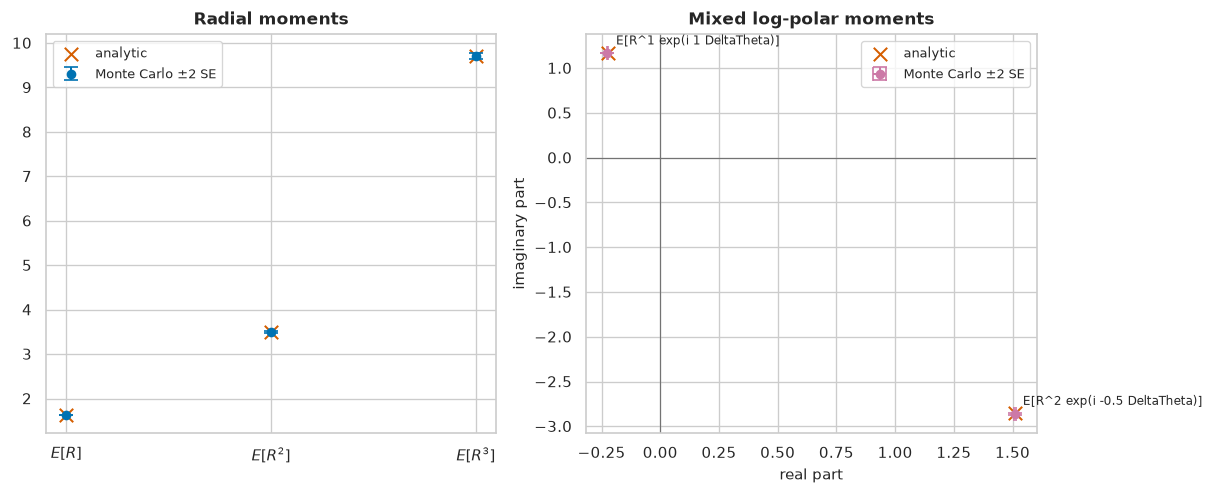

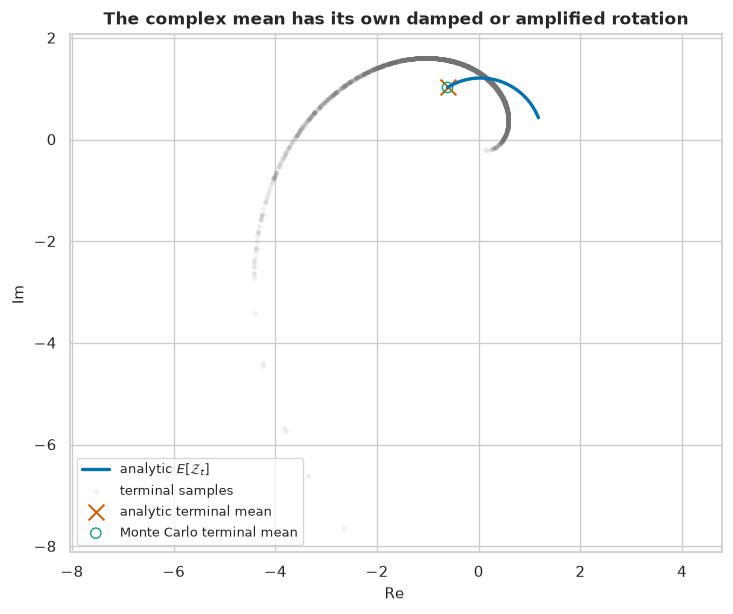

,quantity,analytic_real,estimate_real,se_real,z_real,analytic_imag,estimate_imag,se_imag,z_imag
0,E[R^1],1.637456,1.638910,0.001163,1.250020,0.000000,0.000000,0.000000,0.000000
1,E[R^2],3.493441,3.497759,0.006156,0.701494,0.000000,0.000000,0.000000,0.000000
2,E[R^3],9.710722,9.711549,0.037738,0.021900,0.000000,0.000000,0.000000,0.000000
3,E[Z^1],-0.611913,-0.614080,0.001598,-1.356358,1.023833,1.024367,0.000949,0.563181
4,E[Z^2],0.314617,0.319348,0.005417,0.873369,-0.931845,-0.934746,0.005227,-0.554892
5,E[R^1 exp(i 1 DeltaTheta)],-0.223744,-0.225597,0.001591,-1.164204,1.171585,1.172830,0.000959,1.297505
6,E[R^2 exp(i -0.5 DeltaTheta)],1.508328,1.510770,0.002035,1.199665,-2.853223,-2.857842,0.006061,-0.762083


In [6]:
n_moment = 600_000
rng_moment = np.random.default_rng(BASE_SEED + 4)
w_terminal = np.sqrt(T) * rng_moment.standard_normal(n_moment)
times_terminal = np.full(n_moment, T)
z_samples = exact_path(times_terminal, w_terminal, Z0, PARAMS)
r_samples = np.abs(z_samples)
theta_increments = OMEGA * T + BETA * w_terminal


def moment_row(name: str, sample: np.ndarray, analytic: complex) -> dict[str, object]:
    sample = np.asarray(sample, dtype=np.complex128)
    estimate = complex(np.mean(sample))
    se_real = float(np.std(sample.real, ddof=1) / np.sqrt(sample.size))
    se_imag = float(np.std(sample.imag, ddof=1) / np.sqrt(sample.size))
    z_real = float((estimate.real - analytic.real) / se_real) if se_real > 0 else 0.0
    z_imag = float((estimate.imag - analytic.imag) / se_imag) if se_imag > 0 else 0.0
    return {
        "quantity": name,
        "analytic_real": analytic.real,
        "estimate_real": estimate.real,
        "se_real": se_real,
        "z_real": z_real,
        "analytic_imag": analytic.imag,
        "estimate_imag": estimate.imag,
        "se_imag": se_imag,
        "z_imag": z_imag,
    }


moment_rows = []
for order in [1, 2, 3]:
    moment_rows.append(
        moment_row(
            f"E[R^{order}]",
            r_samples**order,
            complex(radial_moment(R0, T, order, PARAMS)),
        )
    )
for order in [1, 2]:
    moment_rows.append(
        moment_row(
            f"E[Z^{order}]",
            z_samples**order,
            complex_moment(Z0, T, order, PARAMS),
        )
    )
for p, q in [(1.0, 1.0), (2.0, -0.5)]:
    moment_rows.append(
        moment_row(
            f"E[R^{p:g} exp(i {q:g} DeltaTheta)]",
            r_samples**p * np.exp(1j * q * theta_increments),
            mixed_log_polar_moment(R0, T, p, q, PARAMS),
        )
    )
moment_table = pd.DataFrame(moment_rows)
max_standardized_residual = float(
    moment_table[["z_real", "z_imag"]].abs().to_numpy().max()
)
assert max_standardized_residual < 3.0
write_csv("moment_validation.csv", moment_table)

radial_rows = moment_table.iloc[:3]
x_positions = np.arange(3)
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.2))
axes[0].errorbar(
    x_positions,
    radial_rows["estimate_real"],
    yerr=2 * radial_rows["se_real"],
    fmt="o",
    capsize=4,
    color=COLORS["blue"],
    label="Monte Carlo ±2 SE",
)
axes[0].scatter(
    x_positions, radial_rows["analytic_real"],
    marker="x", s=65, color=COLORS["red"], label="analytic"
)
axes[0].set_xticks(x_positions, [r"$E[R]$", r"$E[R^2]$", r"$E[R^3]$"])
axes[0].set_title("Radial moments")
axes[0].legend()
mixed_rows = moment_table.iloc[-2:]
axes[1].errorbar(
    mixed_rows["estimate_real"], mixed_rows["estimate_imag"],
    xerr=2 * mixed_rows["se_real"], yerr=2 * mixed_rows["se_imag"],
    fmt="o", capsize=4, color=COLORS["purple"], label="Monte Carlo ±2 SE"
)
axes[1].scatter(
    mixed_rows["analytic_real"], mixed_rows["analytic_imag"],
    marker="x", s=65, color=COLORS["red"], label="analytic"
)
for _, row in mixed_rows.iterrows():
    axes[1].annotate(
        row["quantity"], (row["analytic_real"], row["analytic_imag"]),
        xytext=(5, 5), textcoords="offset points", fontsize=7
    )
axes[1].axhline(0.0, color=COLORS["gray"], lw=0.7)
axes[1].axvline(0.0, color=COLORS["gray"], lw=0.7)
axes[1].set_xlabel("real part")
axes[1].set_ylabel("imaginary part")
axes[1].set_title("Mixed log-polar moments")
axes[1].legend()
fig.tight_layout()
save_figure(
    fig,
    "f13_moment_validation",
    "Analytic radial and mixed log-polar moments agree with seeded Monte Carlo estimates and their componentwise two-standard-error bars.",
)

mean_path_times = np.linspace(0.0, T, 400)
analytic_mean_path = np.array(
    [complex_moment(Z0, time, 1, PARAMS) for time in mean_path_times]
)
mean_estimate = complex(np.mean(z_samples))
mean_analytic = complex_moment(Z0, T, 1, PARAMS)
fig, ax = plt.subplots(figsize=(7.0, 5.6))
ax.plot(
    analytic_mean_path.real, analytic_mean_path.imag,
    color=COLORS["blue"], lw=2.0, label=r"analytic $E[\mathcal{Z}_t]$"
)
ax.scatter(
    z_samples.real[::250], z_samples.imag[::250],
    s=5, alpha=0.08, color=COLORS["gray"], rasterized=True,
    label="terminal samples"
)
ax.scatter(
    [mean_analytic.real], [mean_analytic.imag],
    marker="x", s=90, color=COLORS["red"], label="analytic terminal mean"
)
ax.scatter(
    [mean_estimate.real], [mean_estimate.imag],
    marker="o", s=38, facecolor="none", edgecolor=COLORS["green"],
    label="Monte Carlo terminal mean"
)
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel(r"$\operatorname{Re}$")
ax.set_ylabel(r"$\operatorname{Im}$")
ax.set_title("The complex mean has its own damped or amplified rotation")
ax.legend(loc="best")
save_figure(
    fig,
    "f14_complex_mean_geometry",
    "The analytic complex mean traces a deterministic curve through time and ends at the same point as the seeded Monte Carlo terminal mean.",
)
moment_table

## 6. Phase 3 is a constrained subfamily

Phase 3 used \(Z_t=Z_0e^{(1+i\gamma)L_t}\) with the GBM log return

\[
L_t=\left(\mu-\frac12\sigma^2\right)t+\sigma W_t.
\]

Matching the Phase 4 exponent requires

\[
\beta=\gamma\sigma,\qquad
\omega=\gamma\left(\mu-\frac12\sigma^2\right).
\]

The identities are exact on every path. Phase 4 releases this fixed
proportionality and allows deterministic and stochastic rotation to
be specified independently.

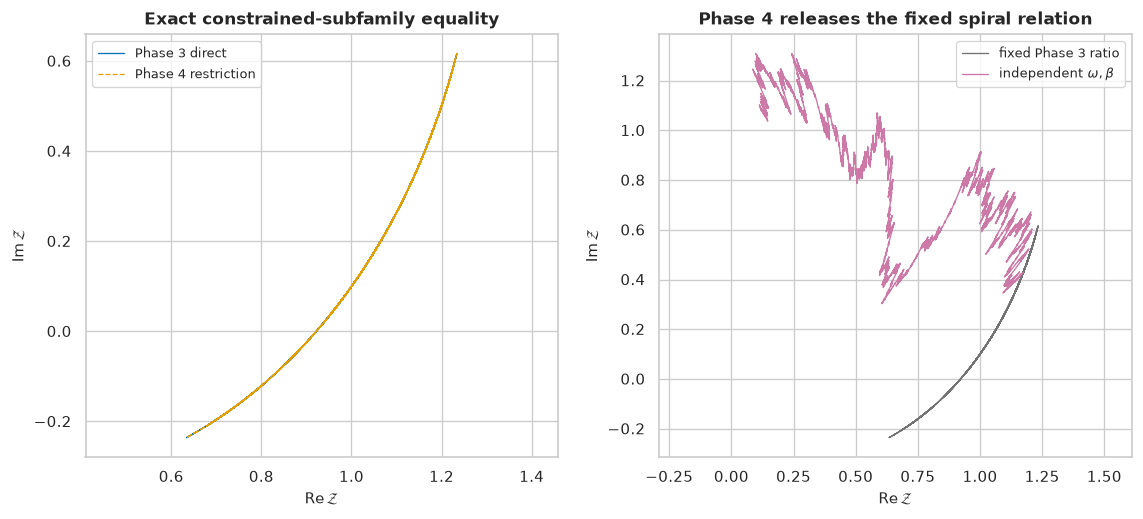

{'beta': 0.48299999999999993,
 'gamma': 1.15,
 'max_pathwise_error': 2.7336071744532853e-16,
 'omega': 0.10557,
 'restriction_beta_equals_gamma_sigma': True,
 'restriction_omega_equals_gamma_log_drift': True}

In [7]:
GAMMA = 1.15
phase3_beta = GAMMA * SIGMA
phase3_omega = GAMMA * (MU - 0.5 * SIGMA**2)
phase3_params = ComplexGBMParameters(
    MU, SIGMA, phase3_omega, phase3_beta
)
phase4_subfamily = exact_path(times, brownian, Z0, phase3_params)
log_return = (MU - 0.5 * SIGMA**2) * times + SIGMA * brownian
phase3_direct = Z0 * np.exp((1.0 + 1j * GAMMA) * log_return)
phase3_error = float(np.max(np.abs(phase4_subfamily - phase3_direct)))
assert phase3_error < 2e-13
phase3_payload = {
    "beta": phase3_beta,
    "gamma": GAMMA,
    "max_pathwise_error": phase3_error,
    "omega": phase3_omega,
    "restriction_beta_equals_gamma_sigma": True,
    "restriction_omega_equals_gamma_log_drift": True,
}
write_json("phase3_equivalence.json", phase3_payload)

independent_params = ComplexGBMParameters(MU, SIGMA, 0.85, 0.25)
independent_path = exact_path(times, brownian, Z0, independent_params)
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4))
axes[0].plot(
    phase3_direct.real, phase3_direct.imag,
    color=COLORS["blue"], lw=0.8, label="Phase 3 direct"
)
axes[0].plot(
    phase4_subfamily.real, phase4_subfamily.imag,
    color=COLORS["orange"], lw=0.8, ls="--", label="Phase 4 restriction"
)
axes[0].set_title("Exact constrained-subfamily equality")
axes[0].legend()
axes[1].plot(
    phase4_subfamily.real, phase4_subfamily.imag,
    color=COLORS["gray"], lw=0.8, label="fixed Phase 3 ratio"
)
axes[1].plot(
    independent_path.real, independent_path.imag,
    color=COLORS["purple"], lw=0.8,
    label=r"independent $\omega,\beta$"
)
axes[1].set_title("Phase 4 releases the fixed spiral relation")
axes[1].legend()
for ax in axes:
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel(r"$\operatorname{Re}\mathcal{Z}$")
    ax.set_ylabel(r"$\operatorname{Im}\mathcal{Z}$")
fig.tight_layout()
save_figure(
    fig,
    "f15_phase3_subfamily",
    "The Phase 3 logarithmic-spiral formula exactly overlaps the restricted Phase 4 process, while independently chosen phase parameters produce a different path.",
)
phase3_payload

## 7. Euler--Maruyama and complex quadratic variation

Euler--Maruyama applied to

\[
d\mathcal{Z}_t=A\mathcal{Z}_t\,dt+B\mathcal{Z}_t\,dW_t
\]

has strong order \(1/2\) in the usual globally Lipschitz linear
setting. Shared Brownian paths isolate discretization error across
levels.

Two complex brackets carry different information:

\[
d[\mathcal{Z},\mathcal{Z}]_t=B^2\mathcal{Z}_t^2\,dt,\qquad
d[\mathcal{Z},\overline{\mathcal{Z}}]_t
=|B|^2|\mathcal{Z}_t|^2\,dt.
\]

The first is bilinear and complex; the second is Hermitian,
nonnegative, and measures total planar quadratic variation.

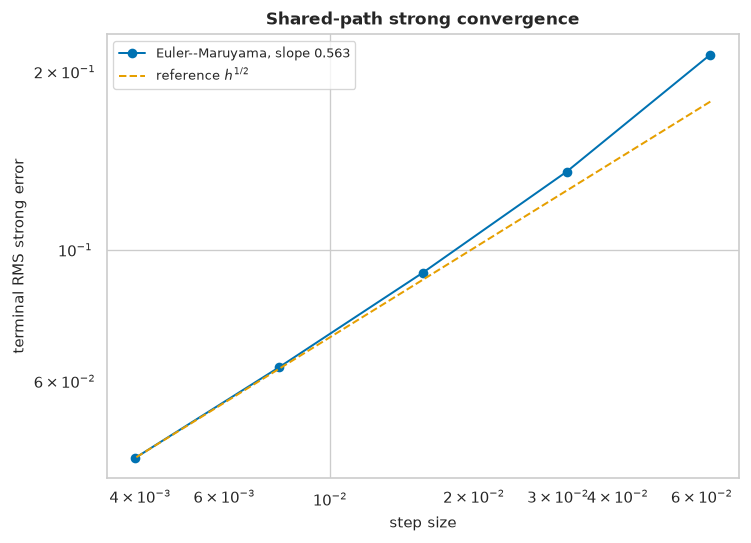

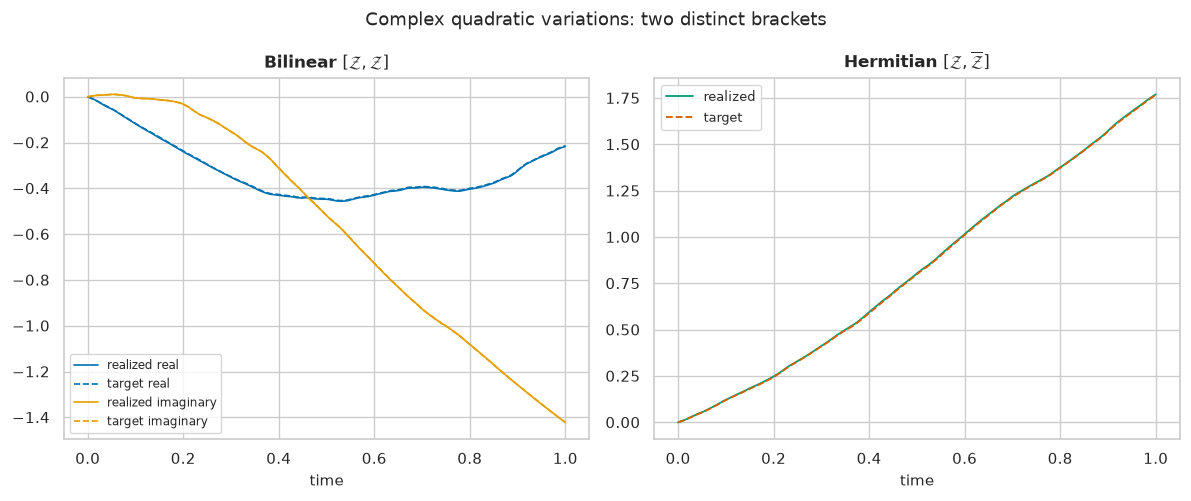

(   steps  step_size  rms_strong_error  fitted_slope  paths
 0     16   0.062500          0.213711      0.562511  12000
 1     32   0.031250          0.135482      0.562511  12000
 2     64   0.015625          0.091478      0.562511  12000
 3    128   0.007812          0.063310      0.562511  12000
 4    256   0.003906          0.044501      0.562511  12000,
      bracket  realized_real  realized_imag  target_real  target_imag  \
 0   bilinear      -0.216683      -1.421667    -0.214015    -1.421481   
 1  hermitian       1.770592       0.000000     1.767283     0.000000   
 
    relative_error   steps  
 0        0.001860  262144  
 1        0.001872  262144  )

In [8]:
convergence_T = 1.0
n_fine = 512
n_convergence_paths = 12_000
rng_convergence = np.random.default_rng(BASE_SEED + 5)
fine_h = convergence_T / n_fine
fine_dW = np.sqrt(fine_h) * rng_convergence.standard_normal(
    (n_convergence_paths, n_fine)
)
endpoint_w = fine_dW.sum(axis=1)
exact_endpoint = Z0 * np.exp(kappa * convergence_T + B * endpoint_w)
levels = np.array([16, 32, 64, 128, 256])
errors = []
for n_steps in levels:
    block = n_fine // n_steps
    coarse_dW = fine_dW.reshape(
        n_convergence_paths, n_steps, block
    ).sum(axis=2)
    h = convergence_T / n_steps
    em_endpoint = Z0 * np.prod(
        1.0 + A * h + B * coarse_dW,
        axis=1,
    )
    error = float(np.sqrt(np.mean(np.abs(em_endpoint - exact_endpoint) ** 2)))
    errors.append(error)
step_sizes = convergence_T / levels
strong_slope, strong_intercept = np.polyfit(
    np.log(step_sizes), np.log(errors), 1
)
assert 0.42 <= strong_slope <= 0.65
convergence_table = pd.DataFrame(
    {
        "steps": levels,
        "step_size": step_sizes,
        "rms_strong_error": errors,
        "fitted_slope": [strong_slope] * len(levels),
        "paths": [n_convergence_paths] * len(levels),
    }
)
write_csv("strong_convergence.csv", convergence_table)

fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.loglog(
    step_sizes, errors, "o-", color=COLORS["blue"],
    label=f"Euler--Maruyama, slope {strong_slope:.3f}"
)
reference = np.asarray(errors[-1]) * (step_sizes / step_sizes[-1]) ** 0.5
ax.loglog(
    step_sizes, reference, "--", color=COLORS["orange"],
    label=r"reference $h^{1/2}$"
)
ax.set_xlabel("step size")
ax.set_ylabel("terminal RMS strong error")
ax.set_title("Shared-path strong convergence")
ax.legend()
save_figure(
    fig,
    "f16_strong_convergence",
    "A log-log plot of Euler--Maruyama terminal root-mean-square error follows the reference square-root step-size line on shared Brownian paths.",
)

bracket_T = 1.0
bracket_steps = 262_144
bracket_h = bracket_T / bracket_steps
rng_bracket = np.random.default_rng(BASE_SEED + 6)
bracket_dW = np.sqrt(bracket_h) * rng_bracket.standard_normal(bracket_steps)
bracket_times = np.linspace(0.0, bracket_T, bracket_steps + 1)
bracket_w = np.concatenate(([0.0], np.cumsum(bracket_dW)))
bracket_z = exact_path(bracket_times, bracket_w, Z0, PARAMS)
dz = np.diff(bracket_z)
realized_bilinear_cumulative = np.cumsum(dz**2)
target_bilinear_cumulative = np.cumsum(
    B**2 * bracket_z[:-1] ** 2 * bracket_h
)
realized_hermitian_cumulative = np.cumsum(np.abs(dz) ** 2)
target_hermitian_cumulative = np.cumsum(
    abs(B) ** 2 * np.abs(bracket_z[:-1]) ** 2 * bracket_h
)
bilinear_relative_error = float(
    abs(realized_bilinear_cumulative[-1] - target_bilinear_cumulative[-1])
    / max(abs(target_bilinear_cumulative[-1]), 1e-15)
)
hermitian_relative_error = float(
    abs(realized_hermitian_cumulative[-1] - target_hermitian_cumulative[-1])
    / target_hermitian_cumulative[-1]
)
assert bilinear_relative_error < 0.02
assert hermitian_relative_error < 0.02

bracket_table = pd.DataFrame(
    [
        {
            "bracket": "bilinear",
            "realized_real": realized_bilinear_cumulative[-1].real,
            "realized_imag": realized_bilinear_cumulative[-1].imag,
            "target_real": target_bilinear_cumulative[-1].real,
            "target_imag": target_bilinear_cumulative[-1].imag,
            "relative_error": bilinear_relative_error,
            "steps": bracket_steps,
        },
        {
            "bracket": "hermitian",
            "realized_real": realized_hermitian_cumulative[-1],
            "realized_imag": 0.0,
            "target_real": target_hermitian_cumulative[-1],
            "target_imag": 0.0,
            "relative_error": hermitian_relative_error,
            "steps": bracket_steps,
        },
    ]
)
write_csv("quadratic_variation.csv", bracket_table)

bracket_view = np.linspace(0, bracket_steps - 1, 2500, dtype=int)
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
axes[0].plot(
    bracket_times[1:][bracket_view],
    realized_bilinear_cumulative.real[bracket_view],
    color=COLORS["blue"], lw=1.0, label="realized real"
)
axes[0].plot(
    bracket_times[1:][bracket_view],
    target_bilinear_cumulative.real[bracket_view],
    color=COLORS["blue"], lw=1.0, ls="--", label="target real"
)
axes[0].plot(
    bracket_times[1:][bracket_view],
    realized_bilinear_cumulative.imag[bracket_view],
    color=COLORS["orange"], lw=1.0, label="realized imaginary"
)
axes[0].plot(
    bracket_times[1:][bracket_view],
    target_bilinear_cumulative.imag[bracket_view],
    color=COLORS["orange"], lw=1.0, ls="--", label="target imaginary"
)
axes[0].set_title(r"Bilinear $[\mathcal{Z},\mathcal{Z}]$")
axes[0].set_xlabel("time")
axes[0].legend(fontsize=7)
axes[1].plot(
    bracket_times[1:][bracket_view],
    realized_hermitian_cumulative[bracket_view],
    color=COLORS["green"], lw=1.1, label="realized"
)
axes[1].plot(
    bracket_times[1:][bracket_view],
    target_hermitian_cumulative[bracket_view],
    color=COLORS["red"], lw=1.1, ls="--", label="target"
)
axes[1].set_title(r"Hermitian $[\mathcal{Z},\overline{\mathcal{Z}}]$")
axes[1].set_xlabel("time")
axes[1].legend()
fig.suptitle("Complex quadratic variations: two distinct brackets")
fig.tight_layout()
save_figure(
    fig,
    "f17_complex_quadratic_variation",
    "Cumulative realized bilinear and Hermitian complex quadratic variations track their analytic time-integral targets, with the bilinear bracket split into real and imaginary parts.",
)
convergence_table, bracket_table

## 8. Synthesis and artifact manifest

The direct complex exponential, exact multiplicative transition,
complex Itô SDE, and stochastic exponential are four consistent views
of one process. Their shared driver creates exact scale--rotation
coupling but only one stochastic direction. A second independent
Brownian driver is a model extension, not an algebraic rewrite.

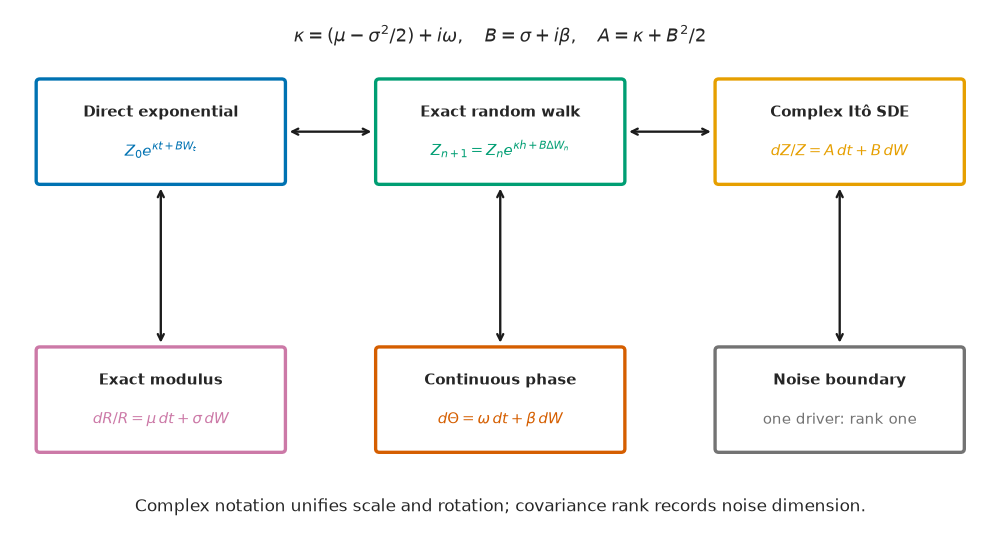

PHASE4_DETERMINISTIC_SUMMARY
{"bilinear_qv_error": "0.001860", "figures": 18, "hermitian_qv_error": "0.001872", "max_exactness_error": "6.661338e-16", "max_moment_z": "1.356358", "strong_slope": "0.562511", "table_hashes": {"coefficient_reconciliation.csv": "650fbfa8478bde134c837396eb917dfbecdf859acfbb555113d26bd7e5c62be9", "covariance_rank.csv": "a4527c0335db4529294bffa660d505c95cfc7df8e7d30c670734a070b151603c", "exactness.json": "76670be10a430a15d93c9cd69a164e2a406ee94ed6116e8ab88c9661f135528b", "figure_manifest.csv": "0632c400b0cd7b5b1c289e01bde96324fbf21928e719dcb25c08bcc17ef46e55", "moment_validation.csv": "568b8cdaac0b4a28785b5e71a57763555894d11d04c03641a08027778f0fb22f", "numerical_summary.json": "b6672d4bc0986a33af038a54a765d1aead47ba224328345bfa7ae0c633f0170f", "phase3_equivalence.json": "4e5003ff779c6fd430e9bd0d65599fb106f2a328d5fadcc121ff479249fa5dfc", "quadratic_variation.csv": "99dac7bbf361206aa025a9d772d972d865686b42678d66670ebb2d67ca8f6c34", "software_versions.csv": "ba2

{'bilinear_bracket_relative_error': 0.0018600483910582175,
 'coefficient_error': 0.0,
 'constant_modulus_error': 4.440892098500626e-16,
 'figure_count': 18,
 'hermitian_bracket_relative_error': 0.0018723122493216912,
 'max_exactness_error': 6.661338147750939e-16,
 'max_moment_standardized_residual': 1.3563577471871175,
 'one_driver_eigenvalue_ratio': 5.538292448590374e-16,
 'phase3_pathwise_error': 2.7336071744532853e-16,
 'strong_convergence_slope': 0.562511466542004,
 'two_driver_numerical_rank': 2}

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.set_xlim(0, 10.5)
ax.set_ylim(0, 6.0)
ax.axis("off")
taxonomy = [
    (0.3, 4.1, 2.6, 1.1, "Direct exponential",
     r"$Z_0e^{\kappa t+BW_t}$", COLORS["blue"]),
    (3.95, 4.1, 2.6, 1.1, "Exact random walk",
     r"$Z_{n+1}=Z_ne^{\kappa h+B\Delta W_n}$", COLORS["green"]),
    (7.6, 4.1, 2.6, 1.1, "Complex Itô SDE",
     r"$dZ/Z=A\,dt+B\,dW$", COLORS["orange"]),
    (0.3, 1.1, 2.6, 1.1, "Exact modulus",
     r"$dR/R=\mu\,dt+\sigma\,dW$", COLORS["purple"]),
    (3.95, 1.1, 2.6, 1.1, "Continuous phase",
     r"$d\Theta=\omega\,dt+\beta\,dW$", COLORS["red"]),
    (7.6, 1.1, 2.6, 1.1, "Noise boundary",
     "one driver: rank one", COLORS["gray"]),
]
for x, y, width, height, heading, formula, color in taxonomy:
    box = patches.FancyBboxPatch(
        (x, y), width, height, boxstyle="round,pad=0.04",
        facecolor="white", edgecolor=color, linewidth=2
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + 0.72, heading, ha="center", weight="bold")
    ax.text(x + width / 2, y + 0.28, formula, ha="center", color=color)
arrow = dict(arrowstyle="<->", color=COLORS["black"], lw=1.4)
ax.annotate("", xy=(3.9, 4.65), xytext=(2.95, 4.65), arrowprops=arrow)
ax.annotate("", xy=(7.55, 4.65), xytext=(6.6, 4.65), arrowprops=arrow)
ax.annotate("", xy=(1.6, 4.05), xytext=(1.6, 2.25), arrowprops=arrow)
ax.annotate("", xy=(5.25, 4.05), xytext=(5.25, 2.25), arrowprops=arrow)
ax.annotate("", xy=(8.9, 4.05), xytext=(8.9, 2.25), arrowprops=arrow)
ax.text(
    5.25, 5.65,
    r"$\kappa=(\mu-\sigma^2/2)+i\omega,\quad B=\sigma+i\beta,\quad A=\kappa+B^2/2$",
    ha="center", fontsize=11
)
ax.text(
    5.25, 0.40,
    "Complex notation unifies scale and rotation; covariance rank records noise dimension.",
    ha="center", fontsize=10
)
save_figure(
    fig,
    "f18_representation_taxonomy",
    "A taxonomy links the direct exponential, exact random walk, complex Itô SDE, exact GBM modulus, continuous phase, and rank-one noise boundary.",
)

numerical_summary = {
    "bilinear_bracket_relative_error": bilinear_relative_error,
    "coefficient_error": coefficient_error,
    "constant_modulus_error": constant_modulus_error,
    "figure_count": len(FIGURE_ROWS),
    "hermitian_bracket_relative_error": hermitian_relative_error,
    "max_exactness_error": max(exactness.values()),
    "max_moment_standardized_residual": max_standardized_residual,
    "one_driver_eigenvalue_ratio": one_ratio,
    "phase3_pathwise_error": phase3_error,
    "strong_convergence_slope": float(strong_slope),
    "two_driver_numerical_rank": int(np.linalg.matrix_rank(empirical_two_cov, tol=1e-4)),
}
write_json("numerical_summary.json", numerical_summary)

figure_manifest = pd.DataFrame(FIGURE_ROWS)
write_csv("figure_manifest.csv", figure_manifest)
planned_tables = [
    "coefficient_reconciliation.csv",
    "covariance_rank.csv",
    "exactness.json",
    "figure_manifest.csv",
    "moment_validation.csv",
    "numerical_summary.json",
    "phase3_equivalence.json",
    "quadratic_variation.csv",
    "software_versions.csv",
    "strong_convergence.csv",
    "table_manifest.csv",
    "transition_summary.csv",
]
table_manifest = pd.DataFrame(
    {
        "name": planned_tables,
        "format": [Path(name).suffix.lstrip(".") for name in planned_tables],
        "purpose": [
            "ordinary and Ito exponential coefficient identity",
            "one-driver and two-driver covariance evidence",
            "pathwise identity tolerances",
            "publication figure paths and alt text",
            "analytic and Monte Carlo moments with uncertainty",
            "headline acceptance metrics",
            "Phase 3 constrained-subfamily identity",
            "bilinear and Hermitian bracket evidence",
            "execution environment record",
            "shared-path Euler--Maruyama convergence",
            "generated table inventory",
            "fixed-horizon transition summaries",
        ],
    }
)
write_csv("table_manifest.csv", table_manifest)

vector_files = sorted(VECTOR_DIR.glob("f*.pdf"))
raster_files = sorted(RASTER_DIR.glob("f*.png"))
assert len(FIGURE_ROWS) == 18
assert len(vector_files) == 18
assert len(raster_files) == 18
assert len({row["stem"] for row in FIGURE_ROWS}) == 18
assert all(len(row["alt_text"]) >= 20 for row in FIGURE_ROWS)
assert all((TABLE_DIR / name).exists() for name in planned_tables)

artifact_hashes = {}
for name in planned_tables:
    content = (TABLE_DIR / name).read_bytes()
    artifact_hashes[name] = hashlib.sha256(content).hexdigest()
stream_summary = {
    "figures": len(FIGURE_ROWS),
    "tables": len(planned_tables),
    "max_exactness_error": f"{max(exactness.values()):.6e}",
    "max_moment_z": f"{max_standardized_residual:.6f}",
    "strong_slope": f"{strong_slope:.6f}",
    "bilinear_qv_error": f"{bilinear_relative_error:.6f}",
    "hermitian_qv_error": f"{hermitian_relative_error:.6f}",
    "table_hashes": artifact_hashes,
}
print("PHASE4_DETERMINISTIC_SUMMARY")
print(json.dumps(stream_summary, sort_keys=True))
print("ALL_PHASE4_ASSERTIONS_PASSED")
numerical_summary